<a href="https://colab.research.google.com/github/reetsharma3381-dev/winner-take-all-music-popularity/blob/main/spotify_econometrics_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spotify Superstar Economics — Colab Notebook

Tests whether Spotify streaming follows a power-law (winner-take-all) distribution,
and whether concentration has risen over time.

**How to use this notebook:** Run every cell top to bottom (Runtime > Run all).
The first few cells install packages and write out the project's Python files
into your Colab session, so everything after that is just calling them.


## 1. Install packages

In [21]:
!pip install -q spotipy powerlaw statsmodels beautifulsoup4 requests pandas numpy matplotlib scipy

## 2. Write out the project's Python files

In [22]:
%%writefile config.py
"""
Configuration for the Spotify Superstar Economics project.
"""

# --- Spotify API credentials ---
# Set these as environment variables before running collect_data.py:
#   export SPOTIPY_CLIENT_ID="your_client_id"
#   export SPOTIPY_CLIENT_SECRET="your_client_secret"
# Get credentials at https://developer.spotify.com/dashboard

# --- Genres to sample artists from (broad coverage reduces genre-specific bias) ---
GENRES = [
    "pop", "hip-hop", "rock", "country", "latin", "edm",
    "r-n-b", "indie", "classical", "jazz", "k-pop", "reggaeton",
]

# --- How many artists to pull per genre per collection run ---
ARTISTS_PER_GENRE = 50

# --- Data storage ---
DATA_DIR = "data"
PANEL_FILE = f"{DATA_DIR}/artist_panel.csv"

# --- Known platform/algorithm shocks for structural break testing ---
# (dates are approximate, used to build era dummies in the regression)
STRUCTURAL_BREAKS = {
    "discover_weekly_launch": "2015-07-01",   # Spotify's algorithmic playlist push
    "tiktok_music_era": "2019-01-01",         # TikTok becomes a major discovery/virality channel
}

# --- Inequality metric settings ---
TOP_SHARES = [0.01, 0.05, 0.10]  # top 1%, 5%, 10% stream/popularity share


Overwriting config.py


In [23]:
%%writefile collect_data.py
"""
collect_data.py
----------------
Pulls artist-level data from the Spotify Web API and appends a timestamped
snapshot to a panel CSV file.

IMPORTANT CAVEAT (read this before you design your paper's data section):
The Spotify Web API does NOT expose raw historical stream counts. The best
available proxies are:
  - `popularity` (0-100 integer, Spotify's own algorithmic popularity score)
  - `followers.total` (artist follower count)
These are cross-sectional-in-time snapshots — Spotify does not let you query
"popularity in 2018" retroactively. To build a genuine time-series panel you
have two options:
  1. Run this script repeatedly over weeks/months to accumulate your own
     panel (slow, but 100% legitimate and defensible methodologically).
  2. Supplement with third-party historical data (e.g., Kworb.net chart
     archives, Chartmetric, or Last.fm scrobble counts) merged in by artist
     name/ID. This is the more common approach in published work on this
     topic, and I'd recommend it for a course-length project.

This script handles option (1) and produces data in the exact shape needed
by the rest of the pipeline. If you already have historical data from
another source, just format it to match the columns in `data/artist_panel.csv`
(see the README) and skip this script.
"""

import os
import time
import datetime
import pandas as pd
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials

import config


def get_client():
    client_id = os.environ.get("SPOTIPY_CLIENT_ID")
    client_secret = os.environ.get("SPOTIPY_CLIENT_SECRET")
    if not client_id or not client_secret:
        raise EnvironmentError(
            "Missing SPOTIPY_CLIENT_ID / SPOTIPY_CLIENT_SECRET environment variables. "
            "Create an app at https://developer.spotify.com/dashboard and set them."
        )
    auth = SpotifyClientCredentials(client_id=client_id, client_secret=client_secret)
    return spotipy.Spotify(client_credentials_manager=auth)


def fetch_artists_for_genre(sp, genre, limit=50):
    """Search for top artists tagged with a genre, paging through results."""
    rows = []
    fetched = 0
    offset = 0
    page_size = 50
    while fetched < limit:
        batch = min(page_size, limit - fetched)
        try:
            results = sp.search(
                q=f'genre:"{genre}"', type="artist", limit=batch, offset=offset
            )
        except Exception as e:
            print(f"  [warn] search failed for genre={genre} offset={offset}: {e}")
            break

        items = results.get("artists", {}).get("items", [])
        if not items:
            break

        for a in items:
            rows.append(
                {
                    "artist_id": a["id"],
                    "artist_name": a["name"],
                    "genre_query": genre,
                    "genres_tagged": ";".join(a.get("genres", [])),
                    "popularity": a.get("popularity"),
                    "followers": a.get("followers", {}).get("total"),
                }
            )
        fetched += len(items)
        offset += len(items)
        time.sleep(0.1)  # be polite to the API
    return rows


def collect_snapshot():
    sp = get_client()
    os.makedirs(config.DATA_DIR, exist_ok=True)

    snapshot_date = datetime.date.today().isoformat()
    all_rows = []
    for genre in config.GENRES:
        print(f"Fetching genre: {genre}")
        rows = fetch_artists_for_genre(sp, genre, limit=config.ARTISTS_PER_GENRE)
        for r in rows:
            r["snapshot_date"] = snapshot_date
        all_rows.extend(rows)
        print(f"  -> {len(rows)} artists")

    df = pd.DataFrame(all_rows)
    if df.empty:
        print("No data collected. Check your credentials and network access.")
        return

    # Deduplicate within this snapshot (an artist can match multiple genre queries)
    df = df.sort_values("popularity", ascending=False).drop_duplicates(
        subset=["artist_id", "snapshot_date"], keep="first"
    )

    if os.path.exists(config.PANEL_FILE):
        existing = pd.read_csv(config.PANEL_FILE)
        combined = pd.concat([existing, df], ignore_index=True)
        combined = combined.drop_duplicates(
            subset=["artist_id", "snapshot_date"], keep="last"
        )
    else:
        combined = df

    combined.to_csv(config.PANEL_FILE, index=False)
    print(f"\nSaved {len(df)} artist rows for {snapshot_date}.")
    print(f"Panel file now has {len(combined)} total rows -> {config.PANEL_FILE}")


if __name__ == "__main__":
    collect_snapshot()


Overwriting collect_data.py


In [24]:
%%writefile collect_kworb_wayback_data.py
"""
collect_kworb_wayback_data.py
--------------------------------
Builds a REAL multi-year artist-level stream panel without waiting months
for live data collection, by pulling historical snapshots of Kworb's
Spotify "Daily Chart - Global" page from the Internet Archive's Wayback
Machine.

WHY THIS WORKS
--------------
kworb.net/spotify/country/global_daily.html only ever shows *today's*
top-200 chart -- there's no per-date URL. But the Wayback Machine has been
crawling and snapshotting that exact page for years. Fetching an archived
snapshot from, say, January 2019 gives you the chart exactly as it looked
that day: rank, artist, track, and that day's stream count for the top 200
tracks worldwide. Pull one snapshot per year and you get a genuine
cross-sectional distribution of streams-across-artists for each year --
precisely the multi-year panel the power-law/inequality analysis needs.

WHAT THIS MEASURES (read before writing your methods section)
---------------------------------------------------------------
This is TOP-200-CHART concentration, not whole-market concentration. It
captures how unequal streaming is *among songs that make the global daily
chart* on a given day -- it says nothing about the much larger number of
artists who never chart at all. This is actually a completely standard
scope restriction in the "superstar economics" literature (e.g. Billboard
Hot 100 concentration studies use exactly this kind of top-chart data), so
it's a legitimate and defensible measure -- just be explicit in your
write-up that your inequality metrics describe concentration *within the
hit-making tier*, not across all artists on Spotify.

Multiple songs by the same artist on the same day's chart are summed
together into one artist-day observation. Featured/collaborating artists
are recorded too (each gets credited with the song's full streams -- a
common simplifying convention; note it as a limitation if you split credit
differently in your write-up).

USAGE
-----
    python collect_kworb_wayback_data.py

Edit SNAPSHOT_DATES below to control which dates get pulled. One date per
year is enough for the year-over-year inequality trend; add more dates
per year (e.g. one per quarter) for finer-grained analysis.
"""

import json
import re
import time
import requests
import pandas as pd
from bs4 import BeautifulSoup

import config

TARGET_PAGE = "kworb.net/spotify/country/global_daily.html"

# One representative date per year. Pick a date unlikely to be a chart
# outlier (avoid Dec 25-31, which is dominated by holiday songs, unless
# you're specifically studying seasonality).
SNAPSHOT_DATES = [
    "2016-06-15",
    "2017-06-15",
    "2018-06-15",
    "2019-06-15",
    "2020-06-15",
    "2021-06-15",
    "2022-06-15",
    "2023-06-15",
    "2024-06-15",
    "2025-06-15",
]

HEADERS = {
    "User-Agent": "Mozilla/5.0 (research script; econometrics coursework; "
                  "contact: replace-with-your-email@example.com)"
}

CDX_API = "http://web.archive.org/cdx/search/cdx"
WAYBACK_BASE = "http://web.archive.org/web"


def find_snapshot(target_url, date_str, search_window_days=10):
    """
    Uses the Wayback CDX API to find the snapshot of `target_url` closest
    to `date_str` (YYYY-MM-DD), searching up to `search_window_days` before
    and after if no exact-day snapshot exists.
    """
    date_compact = date_str.replace("-", "")
    from_date = (pd.Timestamp(date_str) - pd.Timedelta(days=search_window_days)).strftime("%Y%m%d")
    to_date = (pd.Timestamp(date_str) + pd.Timedelta(days=search_window_days)).strftime("%Y%m%d")

    params = {
        "url": target_url,
        "from": from_date,
        "to": to_date,
        "output": "json",
        "filter": "statuscode:200",
        "limit": 50,
    }
    resp = requests.get(CDX_API, params=params, headers=HEADERS, timeout=30)
    resp.raise_for_status()
    rows = resp.json()

    if len(rows) <= 1:  # first row is just the header
        return None

    header, *data_rows = rows
    idx_timestamp = header.index("timestamp")

    # Pick the snapshot timestamp closest to the target date
    target_ts = pd.Timestamp(date_str)
    best_row = min(
        data_rows,
        key=lambda r: abs(pd.Timestamp(r[idx_timestamp][:8]) - target_ts),
    )
    timestamp = best_row[idx_timestamp]
    snapshot_url = f"{WAYBACK_BASE}/{timestamp}/https://{target_url}"
    actual_date = pd.Timestamp(timestamp[:8]).strftime("%Y-%m-%d")
    return snapshot_url, actual_date


ARTIST_HREF_RE = re.compile(r"/spotify/artist/([A-Za-z0-9]+)\.html")


def parse_chart_page(html):
    """
    Parses a Kworb 'Daily Chart - Global' page (archived or live) into a
    list of dicts: one row per (artist, chart entry), with that day's
    stream count. Handles multiple credited artists per track (primary +
    featured "(w/ ...)").
    """
    soup = BeautifulSoup(html, "html.parser")

    # Kworb's chart table is the largest table on the page.
    tables = soup.find_all("table")
    if not tables:
        return []
    chart_table = max(tables, key=lambda t: len(t.find_all("tr")))

    rows = chart_table.find_all("tr")
    records = []

    for tr in rows:
        cells = tr.find_all("td")
        if len(cells) < 7:
            continue  # skip header row / malformed rows

        # Identify which cell holds the artist/title links (has artist hrefs)
        title_cell = None
        for c in cells:
            if c.find("a", href=ARTIST_HREF_RE):
                title_cell = c
                break
        if title_cell is None:
            continue

        artist_links = title_cell.find_all("a", href=ARTIST_HREF_RE)
        artists = []
        for a in artist_links:
            m = ARTIST_HREF_RE.search(a["href"])
            if m:
                artists.append((m.group(1), a.get_text(strip=True)))

        if not artists:
            continue

        # Streams column: Kworb's daily chart has Streams as the first
        # numeric column after Pk/(x?) -- identify by picking the numeric
        # cell that follows the title cell.
        title_idx = cells.index(title_cell)
        streams_val = None
        for c in cells[title_idx + 1:]:
            text = c.get_text(strip=True).replace(",", "")
            if text.lstrip("-").isdigit() and int(text) > 1000:
                streams_val = int(text)
                break

        if streams_val is None:
            continue

        for artist_id, artist_name in artists:
            records.append(
                {
                    "artist_id": artist_id,
                    "artist_name": artist_name,
                    "streams_est": streams_val,
                }
            )

    return records


def build_panel_from_wayback():
    all_rows = []

    for date_str in SNAPSHOT_DATES:
        year = int(date_str[:4])
        print(f"Fetching snapshot near {date_str}...")
        result = find_snapshot(TARGET_PAGE, date_str)
        if result is None:
            print(f"  [warn] no snapshot found near {date_str}, skipping.")
            continue

        snapshot_url, actual_date = result
        print(f"  -> using snapshot from {actual_date} ({snapshot_url})")

        try:
            resp = requests.get(snapshot_url, headers=HEADERS, timeout=30)
            resp.raise_for_status()
        except requests.RequestException as e:
            print(f"  [warn] failed to fetch snapshot: {e}")
            continue

        records = parse_chart_page(resp.text)
        if not records:
            print(f"  [warn] no chart rows parsed for {actual_date}")
            continue

        # Sum multiple chart entries for the same artist on the same day
        df_day = pd.DataFrame(records)
        df_day = (
            df_day.groupby(["artist_id", "artist_name"], as_index=False)
            ["streams_est"].sum()
        )
        df_day["year"] = year
        df_day["snapshot_date"] = actual_date
        df_day["genre_query"] = "unknown"  # Kworb doesn't provide genre

        all_rows.append(df_day)
        print(f"  -> {len(df_day)} unique artists captured")

        time.sleep(1.5)  # be polite to archive.org

    if not all_rows:
        print("\nNo data collected. Check your network connection and the "
              "SNAPSHOT_DATES list.")
        return None

    panel = pd.concat(all_rows, ignore_index=True)
    panel = panel.sort_values(["year", "streams_est"], ascending=[True, False])
    panel.to_csv(config.PANEL_FILE, index=False)
    print(f"\nSaved {len(panel)} rows across {panel['year'].nunique()} years "
          f"-> {config.PANEL_FILE}")
    return panel


if __name__ == "__main__":
    build_panel_from_wayback()


Overwriting collect_kworb_wayback_data.py


In [25]:
%%writefile generate_synthetic_data.py
"""
generate_synthetic_data.py
---------------------------
Generates a realistic synthetic artist panel so you can test/demo the
entire analysis pipeline immediately, without waiting on live Spotify
API collection or sourcing third-party historical data.

The synthetic process is deliberately built to mimic superstar dynamics:
  - streams are drawn from a mixture of log-normal (the bulk) and a
    Pareto tail (the superstars), which is exactly the pattern the
    empirical literature (e.g. Rosen 1981, Chung & Cox 1994) finds in
    real cultural markets.
  - inequality is set to *increase* over the sample years, and a
    structural break is injected around the TikTok-era date so the
    panel regression has a genuine effect to recover.

Replace this with real data (from collect_data.py and/or a third-party
historical source) when you're ready — just match the column schema.
"""

import numpy as np
import pandas as pd
import os

import config

RNG = np.random.default_rng(42)

N_ARTISTS = 1200
YEARS = list(range(2014, 2025))  # 2014-2024 inclusive


def simulate_year_streams(n, year, base_year=2014, breakpoint_year=2019):
    """
    Mixture of log-normal (bulk of artists) + Pareto tail (superstars).
    Inequality (Pareto share and shape) increases after `breakpoint_year`
    to simulate a TikTok/algorithmic-discovery-driven winner-take-all shift.
    """
    years_since_break = max(0, year - breakpoint_year)

    # Pareto tail gets fatter (lower alpha = more inequality) after the break
    base_alpha = 2.6
    alpha = max(1.15, base_alpha - 0.09 * years_since_break)

    # Share of artists drawn from the superstar tail grows slightly over time
    tail_share = min(0.08, 0.03 + 0.004 * years_since_break)

    is_tail = RNG.random(n) < tail_share

    lognormal_part = RNG.lognormal(mean=11.5, sigma=1.1, size=n)  # bulk streams
    pareto_part = (RNG.pareto(alpha, size=n) + 1) * 5_000_000      # superstar streams

    streams = np.where(is_tail, pareto_part, lognormal_part)

    # Slight overall growth in total listening year over year
    growth = 1.0 + 0.04 * (year - base_year)
    streams = streams * growth

    return streams.astype(np.int64)


def build_panel():
    os.makedirs(config.DATA_DIR, exist_ok=True)

    artist_ids = [f"artist_{i:04d}" for i in range(N_ARTISTS)]
    genres = RNG.choice(config.GENRES, size=N_ARTISTS)
    # Give each artist a persistent "quality" draw so rank isn't pure noise year to year
    artist_quality = RNG.normal(0, 1, size=N_ARTISTS)

    rows = []
    for year in YEARS:
        base_streams = simulate_year_streams(N_ARTISTS, year)
        # Blend in persistent quality so high performers tend to stay high performers
        quality_adj = np.exp(artist_quality * 0.3)
        streams = (base_streams * quality_adj).astype(np.int64)

        # popularity score (0-100) as a monotonic, noisy transform of rank
        pct_rank = pd.Series(streams).rank(pct=True).to_numpy()
        popularity = np.clip((pct_rank * 100) + RNG.normal(0, 3, N_ARTISTS), 0, 100).astype(int)

        followers = (streams * RNG.uniform(0.02, 0.06, N_ARTISTS)).astype(np.int64)

        for i in range(N_ARTISTS):
            rows.append(
                {
                    "artist_id": artist_ids[i],
                    "artist_name": f"Artist {i:04d}",
                    "genre_query": genres[i],
                    "genres_tagged": genres[i],
                    "year": year,
                    "snapshot_date": f"{year}-06-15",
                    "streams_est": streams[i],   # SYNTHETIC ONLY - real API won't give this
                    "popularity": popularity[i],
                    "followers": followers[i],
                }
            )

    df = pd.DataFrame(rows)
    df.to_csv(config.PANEL_FILE, index=False)
    print(f"Synthetic panel written to {config.PANEL_FILE}")
    print(f"  {N_ARTISTS} artists x {len(YEARS)} years = {len(df)} rows")
    return df


if __name__ == "__main__":
    build_panel()


Overwriting generate_synthetic_data.py


In [26]:
%%writefile distribution_analysis.py
"""
distribution_analysis.py
--------------------------
Tests whether artist-level streams/popularity follow a power-law (Pareto)
distribution using the Clauset-Shalizi-Newman (2009) method, and compares
the power-law fit against log-normal and exponential alternatives.

Key functions:
  - fit_power_law(data)          -> fitted powerlaw.Fit object
  - compare_distributions(fit)   -> dict of log-likelihood ratio tests
  - rank_size_plot(data, ...)    -> saves a log-log rank-size plot
  - run_by_year(df, value_col)   -> fits the distribution separately per year
"""

import os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import powerlaw

import config

OUT_DIR = "outputs"


def fit_power_law(data, discrete=True):
    """
    Fit a power law to `data` using the Clauset-Shalizi-Newman method.
    `powerlaw.Fit` automatically estimates the optimal xmin (the point
    above which the tail is power-law-like) via KS-statistic minimization,
    rather than assuming the whole distribution is Pareto.
    """
    data = np.asarray(data, dtype=float)
    data = data[data > 0]
    fit = powerlaw.Fit(data, discrete=discrete, verbose=False)
    return fit


def compare_distributions(fit):
    """
    Likelihood-ratio comparisons of power law vs. alternative distributions.
    R > 0 and p < 0.05 means the first distribution in the pair is favored.
    """
    comparisons = {}
    for alt in ["lognormal", "exponential", "truncated_power_law", "stretched_exponential"]:
        R, p = fit.distribution_compare("power_law", alt)
        comparisons[f"power_law_vs_{alt}"] = {"loglikelihood_ratio_R": R, "p_value": p}
    return comparisons


def summarize_fit(fit, label=""):
    comps = compare_distributions(fit)
    summary = {
        "label": label,
        "alpha": fit.power_law.alpha,
        "xmin": fit.power_law.xmin,
        "ks_distance": fit.power_law.D,
        "n_obs_above_xmin": int((fit.data >= fit.power_law.xmin).sum()),
        "n_obs_total": len(fit.data),
    }
    summary.update(comps)
    return summary


def rank_size_plot(data, title, filename):
    os.makedirs(OUT_DIR, exist_ok=True)
    data = np.sort(np.asarray(data, dtype=float))[::-1]
    ranks = np.arange(1, len(data) + 1)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.loglog(ranks, data, marker=".", linestyle="none", markersize=4, alpha=0.6)
    ax.set_xlabel("Rank (log scale)")
    ax.set_ylabel("Streams / Popularity proxy (log scale)")
    ax.set_title(title)
    ax.grid(True, which="both", ls="--", alpha=0.3)
    fig.tight_layout()
    path = os.path.join(OUT_DIR, filename)
    fig.savefig(path, dpi=150)
    plt.close(fig)
    return path


def run_by_year(df, value_col="streams_est", year_col="year"):
    """
    Fits the power law separately for each year in the panel and returns
    a tidy DataFrame of alpha, xmin, KS distance, and distribution
    comparisons over time -- this is the key input for showing whether
    the tail has gotten "fatter" (lower alpha) over time.
    """
    records = []
    for year, sub in df.groupby(year_col):
        fit = fit_power_law(sub[value_col].values)
        summary = summarize_fit(fit, label=str(year))
        summary[year_col] = year
        records.append(summary)
        rank_size_plot(
            sub[value_col].values,
            title=f"Rank-size distribution, {year}",
            filename=f"rank_size_{year}.png",
        )

    result = pd.DataFrame(records).sort_values(year_col)
    os.makedirs(OUT_DIR, exist_ok=True)
    result.to_csv(os.path.join(OUT_DIR, "power_law_fits_by_year.csv"), index=False)
    return result


def plot_alpha_over_time(fit_results, year_col="year"):
    """
    A falling alpha over time = the tail is getting fatter = more
    winner-take-all concentration. This is one of the two headline
    charts for the paper (the other being the Gini/Top-1% trend).
    """
    os.makedirs(OUT_DIR, exist_ok=True)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(fit_results[year_col], fit_results["alpha"], marker="o")
    ax.set_xlabel("Year")
    ax.set_ylabel("Power-law exponent (alpha)")
    ax.set_title("Tail exponent over time (lower = more concentration)")
    ax.grid(True, ls="--", alpha=0.3)
    fig.tight_layout()
    path = os.path.join(OUT_DIR, "alpha_over_time.png")
    fig.savefig(path, dpi=150)
    plt.close(fig)
    return path


if __name__ == "__main__":
    df = pd.read_csv(config.PANEL_FILE)
    value_col = "streams_est" if "streams_est" in df.columns else "popularity"
    results = run_by_year(df, value_col=value_col)
    plot_alpha_over_time(results)
    print(results[["year", "alpha", "xmin", "ks_distance"]])


Overwriting distribution_analysis.py


In [27]:
%%writefile inequality_metrics.py
"""
inequality_metrics.py
-----------------------
Computes standard inequality metrics (Gini coefficient, Theil index,
top-X% share) on artist-level streams/popularity, per year, so you can
chart whether concentration has risen -- the second headline result
for the paper (alongside the falling power-law alpha).
"""

import os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

import config

OUT_DIR = "outputs"


def gini(values):
    """Standard Gini coefficient. 0 = perfect equality, 1 = max inequality."""
    x = np.sort(np.asarray(values, dtype=float))
    n = len(x)
    if n == 0 or x.sum() == 0:
        return np.nan
    cum = np.cumsum(x)
    return (2 * np.sum((np.arange(1, n + 1)) * x) - (n + 1) * cum[-1]) / (n * cum[-1])


def theil(values):
    """Theil's T index. 0 = perfect equality; decomposable into within/between groups."""
    x = np.asarray(values, dtype=float)
    x = x[x > 0]
    n = len(x)
    if n == 0:
        return np.nan
    mean_x = x.mean()
    return np.mean((x / mean_x) * np.log(x / mean_x))


def top_share(values, share):
    """Share of total value held by the top `share` fraction of units (e.g. 0.01 = top 1%)."""
    x = np.sort(np.asarray(values, dtype=float))[::-1]
    n = len(x)
    k = max(1, int(np.ceil(n * share)))
    total = x.sum()
    if total == 0:
        return np.nan
    return x[:k].sum() / total


def theil_decompose_by_group(df, value_col, group_col):
    """
    Decomposes Theil's T into within-group and between-group components.
    Useful for testing e.g. "is rising inequality driven by genre
    concentration (between) or superstars within each genre (within)?"
    """
    x = df[value_col].astype(float)
    total = x.sum()
    if total == 0:
        return {"within": np.nan, "between": np.nan, "total": np.nan}

    overall_mean = x.mean()
    n_total = len(x)

    within = 0.0
    between = 0.0
    for _, sub in df.groupby(group_col):
        n_g = len(sub)
        mean_g = sub[value_col].mean()
        share_g = sub[value_col].sum() / total
        within += share_g * theil(sub[value_col].values)
        if mean_g > 0:
            between += share_g * np.log(mean_g / overall_mean)

    return {"within": within, "between": between, "total": within + between}


def compute_inequality_by_year(df, value_col="streams_est", year_col="year", group_col="genre_query"):
    records = []
    for year, sub in df.groupby(year_col):
        vals = sub[value_col].values
        rec = {
            "year": year,
            "gini": gini(vals),
            "theil": theil(vals),
        }
        for s in config.TOP_SHARES:
            rec[f"top_{int(s*100)}pct_share"] = top_share(vals, s)

        decomp = theil_decompose_by_group(sub, value_col, group_col)
        rec["theil_within_genre"] = decomp["within"]
        rec["theil_between_genre"] = decomp["between"]

        records.append(rec)

    result = pd.DataFrame(records).sort_values("year")
    os.makedirs(OUT_DIR, exist_ok=True)
    result.to_csv(os.path.join(OUT_DIR, "inequality_by_year.csv"), index=False)
    return result


def plot_inequality_trends(inequality_df):
    os.makedirs(OUT_DIR, exist_ok=True)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].plot(inequality_df["year"], inequality_df["gini"], marker="o", label="Gini")
    axes[0].plot(inequality_df["year"], inequality_df["theil"], marker="s", label="Theil")
    axes[0].set_xlabel("Year")
    axes[0].set_ylabel("Inequality index")
    axes[0].set_title("Gini and Theil over time")
    axes[0].legend()
    axes[0].grid(True, ls="--", alpha=0.3)

    for s in config.TOP_SHARES:
        col = f"top_{int(s*100)}pct_share"
        axes[1].plot(inequality_df["year"], inequality_df[col], marker="o", label=f"Top {int(s*100)}%")
    axes[1].set_xlabel("Year")
    axes[1].set_ylabel("Share of total streams")
    axes[1].set_title("Top-share concentration over time")
    axes[1].legend()
    axes[1].grid(True, ls="--", alpha=0.3)

    fig.tight_layout()
    path = os.path.join(OUT_DIR, "inequality_trends.png")
    fig.savefig(path, dpi=150)
    plt.close(fig)
    return path


if __name__ == "__main__":
    df = pd.read_csv(config.PANEL_FILE)
    value_col = "streams_est" if "streams_est" in df.columns else "popularity"
    result = compute_inequality_by_year(df, value_col=value_col)
    plot_inequality_trends(result)
    print(result)


Overwriting inequality_metrics.py


In [28]:
%%writefile panel_regression.py
"""
panel_regression.py
----------------------
Regresses the year-level inequality metrics on time trend + structural-break
era dummies (Discover Weekly launch, TikTok era) to test whether algorithmic
curation / virality platforms are statistically associated with rising
concentration. Also includes an artist-level panel regression relating
individual popularity to genre and time effects, using clustered SEs.
"""

import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

import config


def add_era_dummies(df, year_col="year"):
    df = df.copy()
    dw_year = int(config.STRUCTURAL_BREAKS["discover_weekly_launch"][:4])
    tt_year = int(config.STRUCTURAL_BREAKS["tiktok_music_era"][:4])
    df["post_discover_weekly"] = (df[year_col] >= dw_year).astype(int)
    df["post_tiktok"] = (df[year_col] >= tt_year).astype(int)
    df["time_trend"] = df[year_col] - df[year_col].min()
    return df


def run_inequality_trend_regression(inequality_df, y_col="gini"):
    """
    Time-series regression of a year-level inequality metric on a linear
    trend plus era dummies. With only ~10 annual observations this is a
    low-power test (n=years), so treat it as descriptive/suggestive rather
    than a definitive causal estimate -- the artist-level regression below
    with clustered SEs is the more defensible inferential test.
    """
    data = add_era_dummies(inequality_df)
    formula = f"{y_col} ~ time_trend + post_discover_weekly + post_tiktok"
    model = smf.ols(formula, data=data).fit(cov_type="HC1")
    return model


def run_artist_level_panel_regression(panel_df, value_col="popularity",
                                       year_col="year", genre_col="genre_query",
                                       cluster_col="artist_id"):
    """
    Artist x year panel regression:
        value ~ time_trend + post_discover_weekly + post_tiktok + C(genre)
    with standard errors clustered by artist to account for repeated
    observations of the same artist over time (serial correlation).

    This tests whether, controlling for genre composition, an individual
    artist's expected popularity/streams shifted after each platform-era
    break -- a proxy for whether the *typical* artist's position changed,
    complementary to the aggregate inequality-index regression above.
    """
    data = add_era_dummies(panel_df, year_col=year_col)

    # log-transform the outcome if it's a raw stream/follower count (skewed, >0)
    if data[value_col].min() > 0 and data[value_col].max() > 1000:
        data["_y"] = np.log(data[value_col])
        y_label = f"log({value_col})"
    else:
        data["_y"] = data[value_col]
        y_label = value_col

    formula = f"_y ~ time_trend + post_discover_weekly + post_tiktok + C({genre_col})"
    model = smf.ols(formula, data=data).fit(
        cov_type="cluster", cov_kwds={"groups": data[cluster_col]}
    )
    model._outcome_label = y_label  # stash for reporting
    return model


def summarize_model(model, name=""):
    print(f"\n{'='*70}\n{name}\n{'='*70}")
    print(model.summary())
    return model.summary()


if __name__ == "__main__":
    import inequality_metrics as im

    df = pd.read_csv(config.PANEL_FILE)
    value_col = "streams_est" if "streams_est" in df.columns else "popularity"

    ineq_df = im.compute_inequality_by_year(df, value_col=value_col)
    m1 = run_inequality_trend_regression(ineq_df, y_col="gini")
    summarize_model(m1, name="Aggregate Gini trend regression")

    m2 = run_artist_level_panel_regression(df, value_col=value_col)
    summarize_model(m2, name=f"Artist-level panel regression ({m2._outcome_label})")


Overwriting panel_regression.py


In [29]:
%%writefile main.py
"""
main.py
--------
Runs the full pipeline end-to-end:
  1. Load the artist panel (data/artist_panel.csv)
  2. Fit power-law distributions by year + compare vs. lognormal/exponential
  3. Compute Gini / Theil / top-share inequality by year
  4. Run the structural-break panel regressions
  5. Write all tables/figures to outputs/ and print a plain-text summary

Usage:
    python generate_synthetic_data.py   # if you don't have real data yet
    python main.py
"""

import os
import pandas as pd

import config
import distribution_analysis as da
import inequality_metrics as im
import panel_regression as pr


def main():
    if not os.path.exists(config.PANEL_FILE):
        raise FileNotFoundError(
            f"No panel file found at {config.PANEL_FILE}. "
            f"Run `python generate_synthetic_data.py` for a demo dataset, "
            f"or `python collect_data.py` (run repeatedly over time) for real data."
        )

    df = pd.read_csv(config.PANEL_FILE)
    value_col = "streams_est" if "streams_est" in df.columns else "popularity"
    print(f"Loaded panel: {len(df)} rows, {df['artist_id'].nunique()} unique artists, "
          f"years {df['year'].min()}-{df['year'].max()}")
    print(f"Using '{value_col}' as the streaming-volume proxy.\n")

    # --- 1. Power-law / distributional analysis ---
    print(">>> Fitting power-law distributions by year...")
    fit_results = da.run_by_year(df, value_col=value_col)
    da.plot_alpha_over_time(fit_results)
    print(fit_results[["year", "alpha", "xmin", "ks_distance",
                        "power_law_vs_lognormal"]].to_string(index=False))

    # --- 2. Inequality metrics ---
    print("\n>>> Computing inequality metrics by year...")
    ineq_df = im.compute_inequality_by_year(df, value_col=value_col)
    im.plot_inequality_trends(ineq_df)
    print(ineq_df.to_string(index=False))

    # --- 3. Regressions ---
    print("\n>>> Running structural-break regressions...")
    m1 = pr.run_inequality_trend_regression(ineq_df, y_col="gini")
    pr.summarize_model(m1, name="Aggregate Gini trend regression")

    m2 = pr.run_artist_level_panel_regression(df, value_col=value_col)
    pr.summarize_model(m2, name=f"Artist-level panel regression ({m2._outcome_label})")

    # --- 4. Plain-text summary ---
    alpha_start = fit_results.iloc[0]["alpha"]
    alpha_end = fit_results.iloc[-1]["alpha"]
    gini_start = ineq_df.iloc[0]["gini"]
    gini_end = ineq_df.iloc[-1]["gini"]

    print("\n" + "=" * 70)
    print("SUMMARY")
    print("=" * 70)
    print(f"Power-law exponent (alpha): {alpha_start:.2f} ({fit_results.iloc[0]['year']}) "
          f"-> {alpha_end:.2f} ({fit_results.iloc[-1]['year']})")
    print("  (a falling alpha = fatter tail = more winner-take-all concentration)")
    print(f"Gini coefficient: {gini_start:.3f} -> {gini_end:.3f}")
    print(f"Top 1% share: {ineq_df.iloc[0]['top_1pct_share']:.3f} -> "
          f"{ineq_df.iloc[-1]['top_1pct_share']:.3f}")
    print(f"\nAll figures and tables saved to ./outputs/")


if __name__ == "__main__":
    main()


Overwriting main.py


## 3. Get your data

Pick ONE of the two options below.

**Option A (fast, for testing the pipeline):** generates a realistic fake
dataset so you can see everything work immediately.

**Option B (real data, recommended for your actual paper):** pulls genuine
historical Spotify chart data from 2016-2025 via the Wayback Machine + Kworb.
This takes a few minutes and needs internet access (Colab has this by default).


In [30]:
# OPTION A: synthetic demo data (fast)
#! python generate_synthetic_data.py

In [31]:
# OPTION B: real historical data (uncomment to use instead of Option A)
!python collect_kworb_wayback_data.py

Fetching snapshot near 2016-06-15...
  [warn] no snapshot found near 2016-06-15, skipping.
Fetching snapshot near 2017-06-15...
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/urllib3/connectionpool.py", line 534, in _make_request
    response = conn.getresponse()
  File "/usr/local/lib/python3.13/dist-packages/urllib3/connection.py", line 565, in getresponse
    httplib_response = super().getresponse()
  File "/usr/lib/python3.13/http/client.py", line 1478, in getresponse
    response.begin()
    ~~~~~~~~~~~~~~^^
  File "/usr/lib/python3.13/http/client.py", line 343, in begin
    version, status, reason = self._read_status()
                              ~~~~~~~~~~~~~~~~~^^
  File "/usr/lib/python3.13/http/client.py", line 304, in _read_status
    line = str(self.fp.readline(_MAXLINE + 1), "iso-8859-1")
               ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^
  File "/usr/lib/python3.13/socket.py", line 723, in readinto
    return self._sock.recv_into(b)
      

## 4. Run the full analysis

In [32]:
!python main.py

Loaded panel: 13200 rows, 1200 unique artists, years 2014-2024
Using 'streams_est' as the streaming-volume proxy.

>>> Fitting power-law distributions by year...
/usr/local/lib/python3.13/dist-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/usr/local/lib/python3.13/dist-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/usr/local/lib/python3.13/dist-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distri

## 5. View the figures inline

outputs/alpha_over_time.png


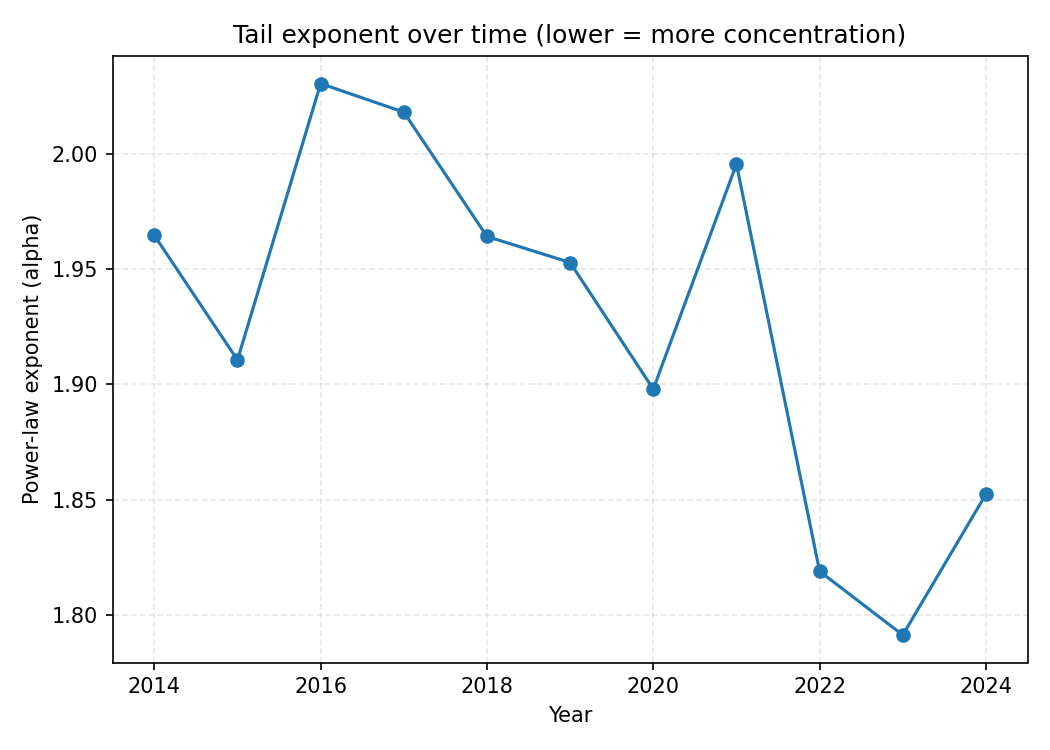

outputs/inequality_trends.png


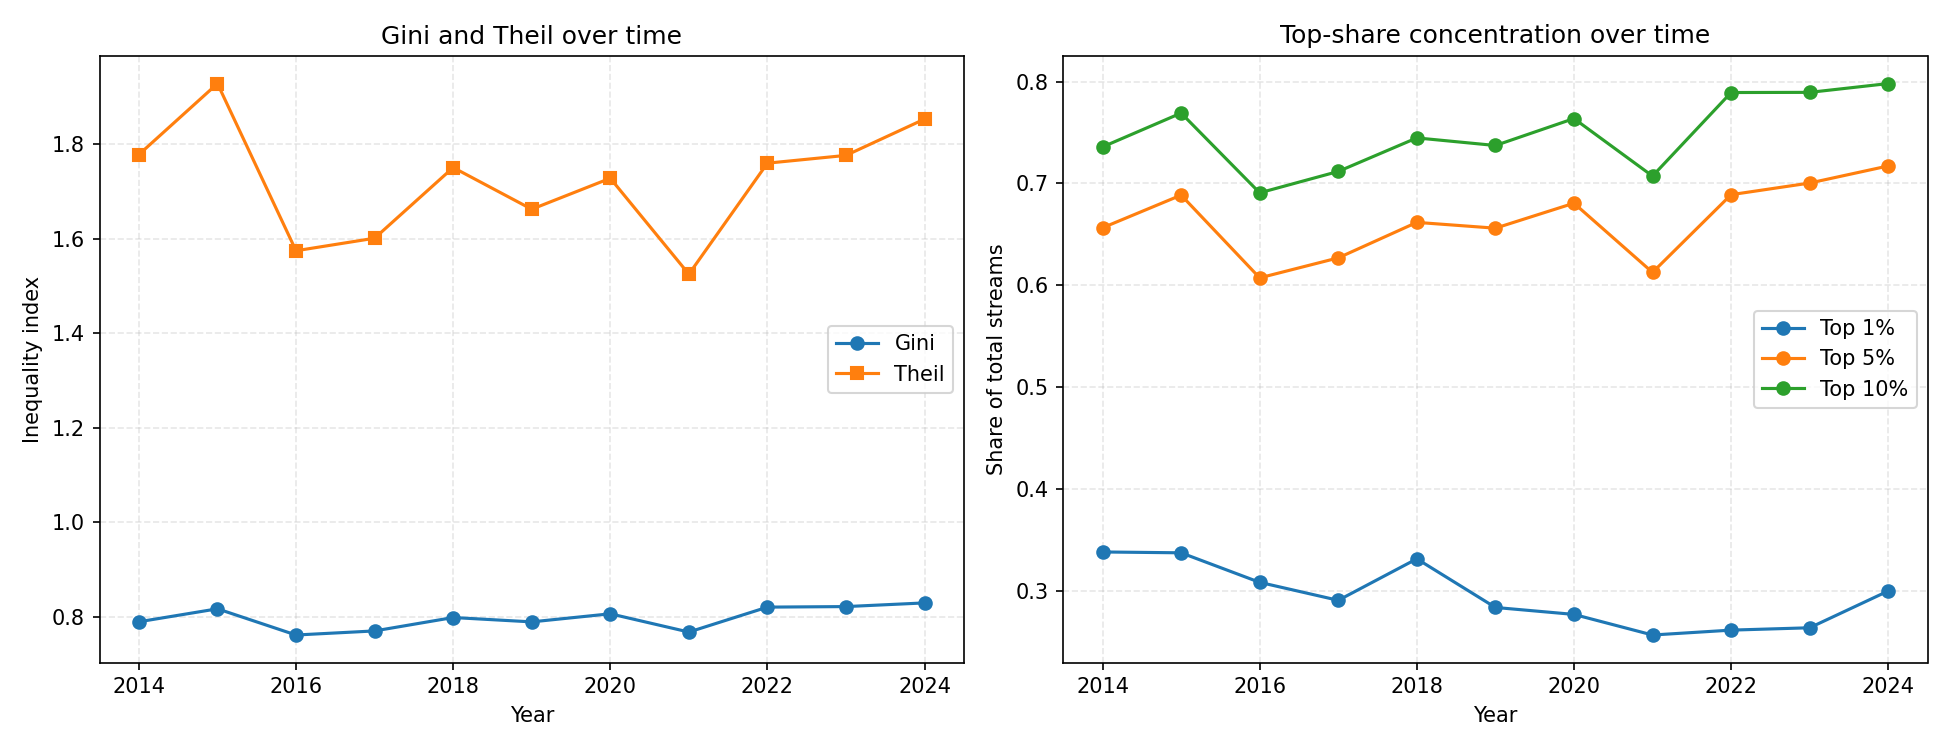

outputs/rank_size_2014.png


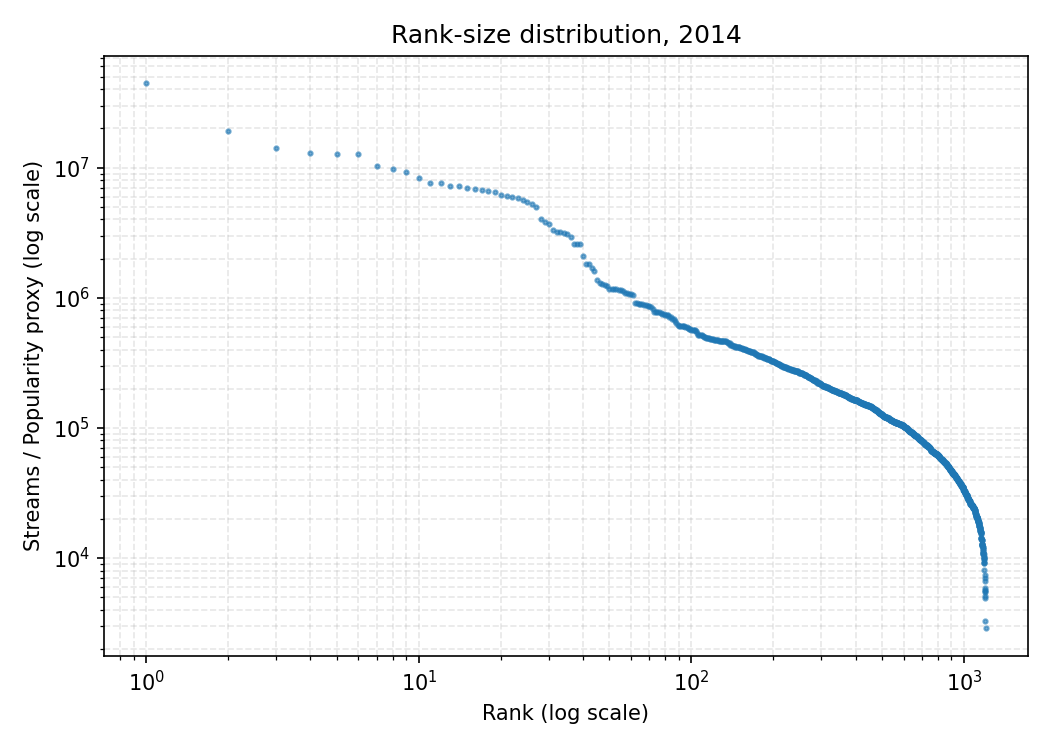

outputs/rank_size_2015.png


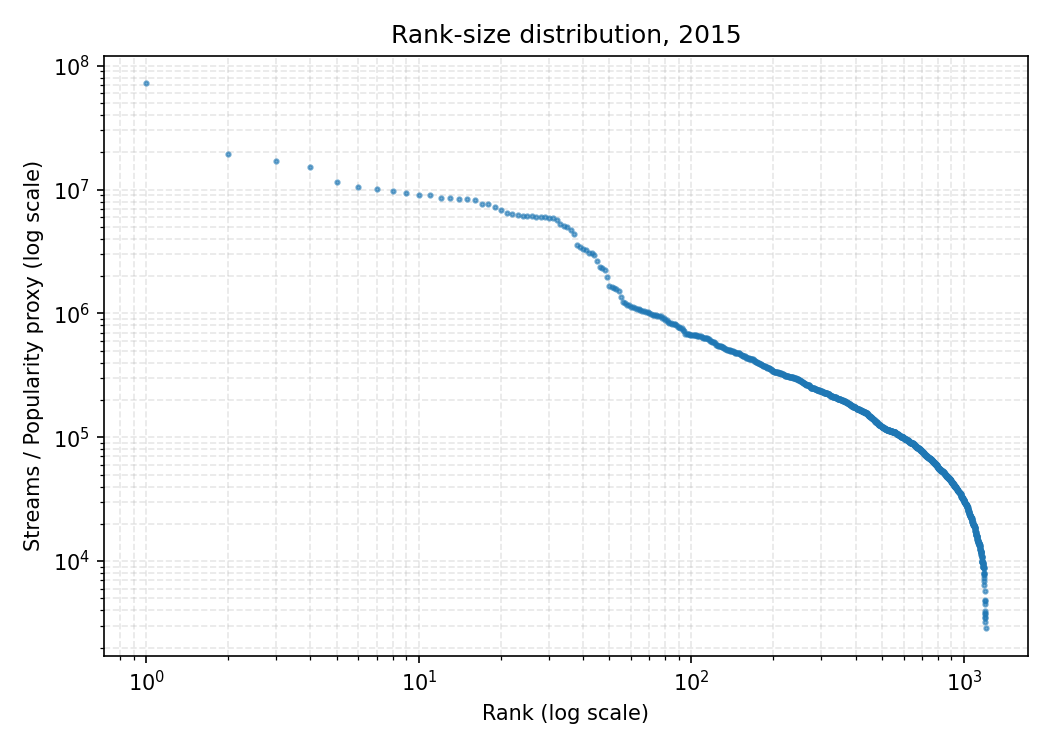

outputs/rank_size_2016.png


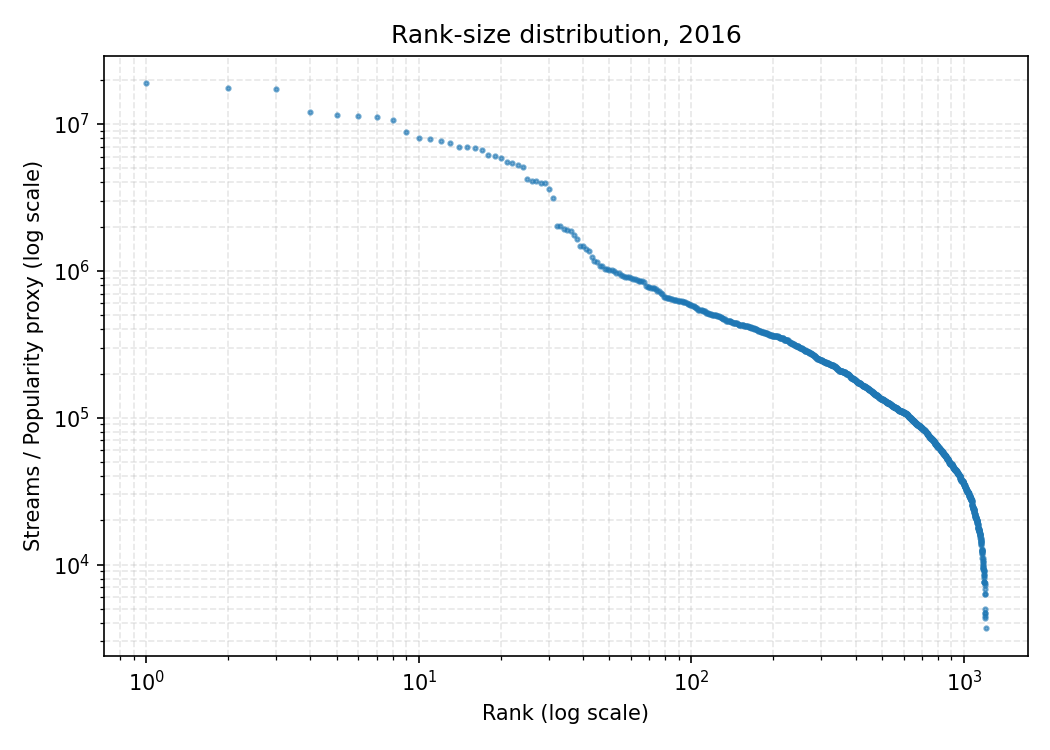

outputs/rank_size_2017.png


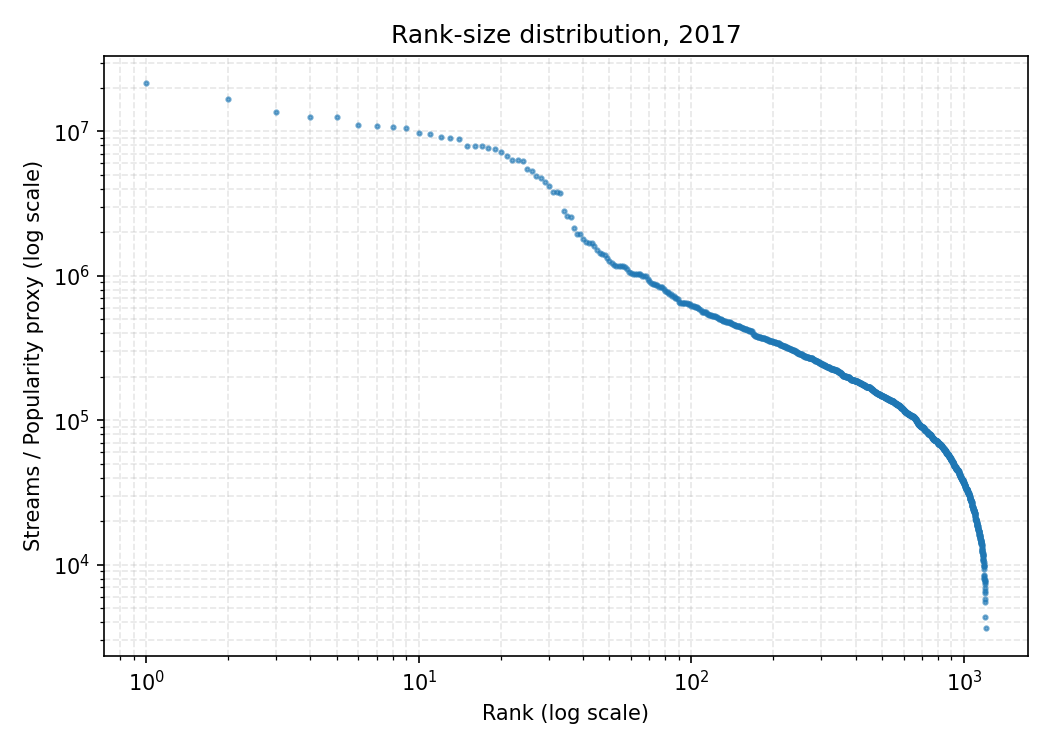

outputs/rank_size_2018.png


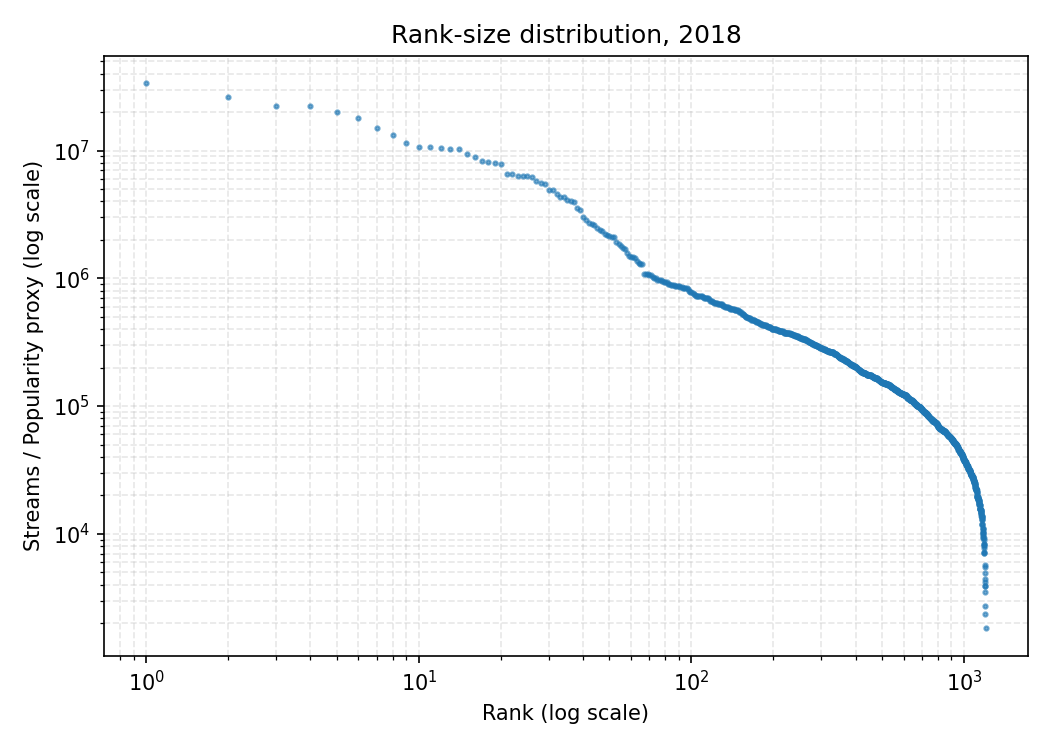

outputs/rank_size_2019.png


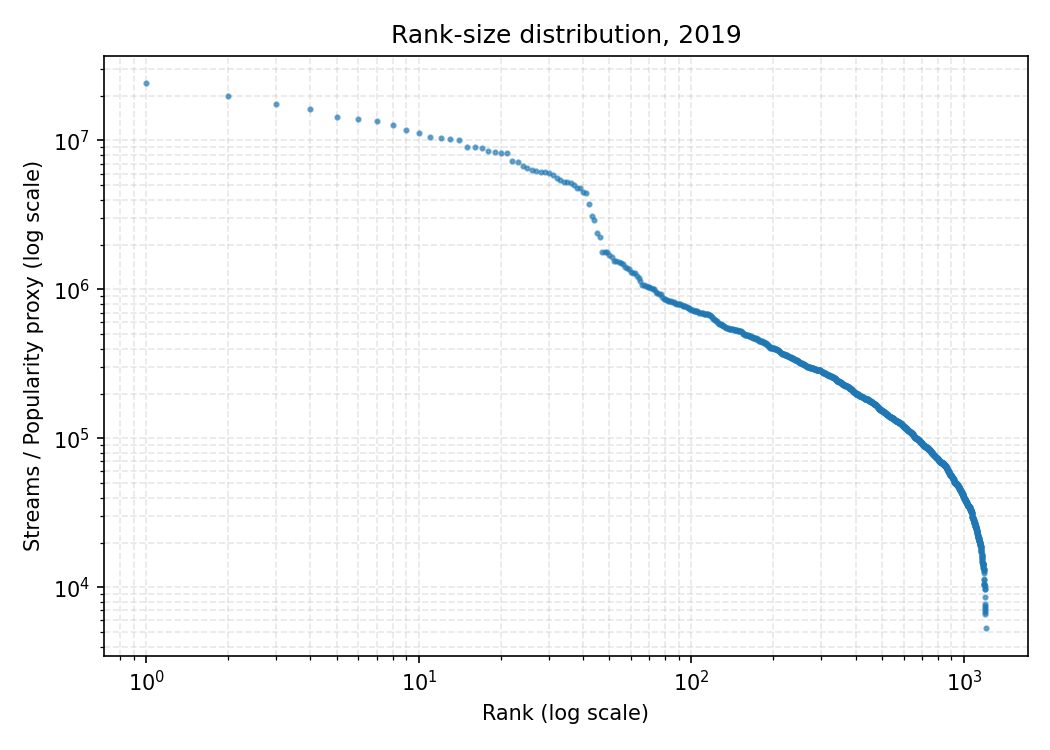

outputs/rank_size_2020.png


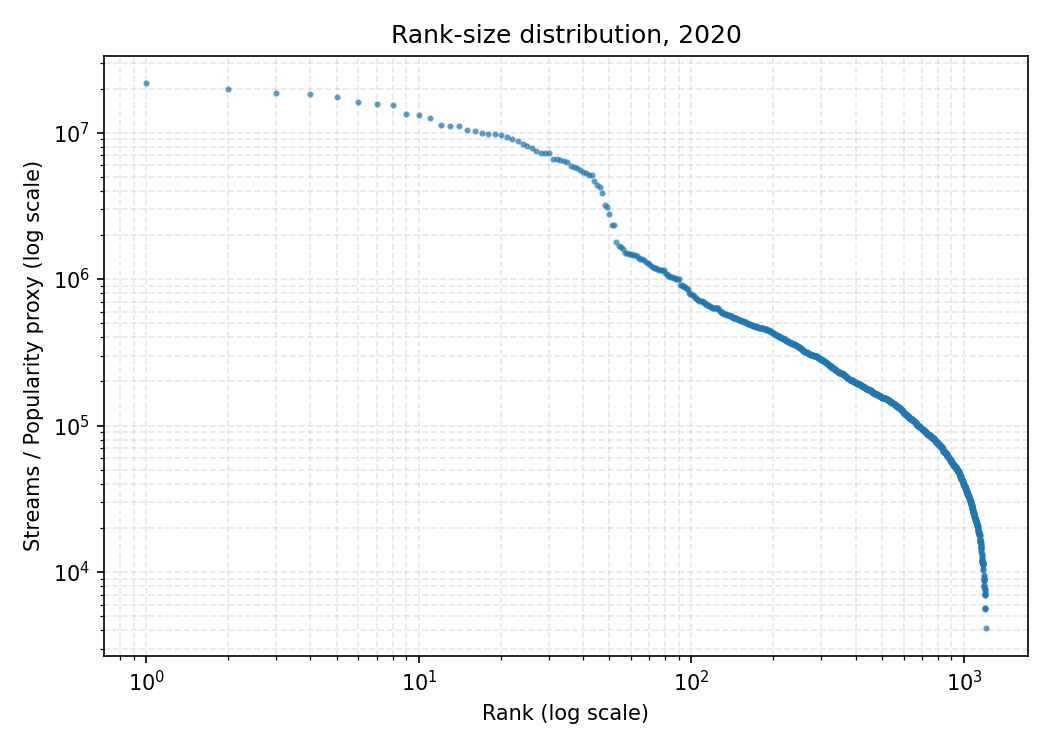

outputs/rank_size_2021.png


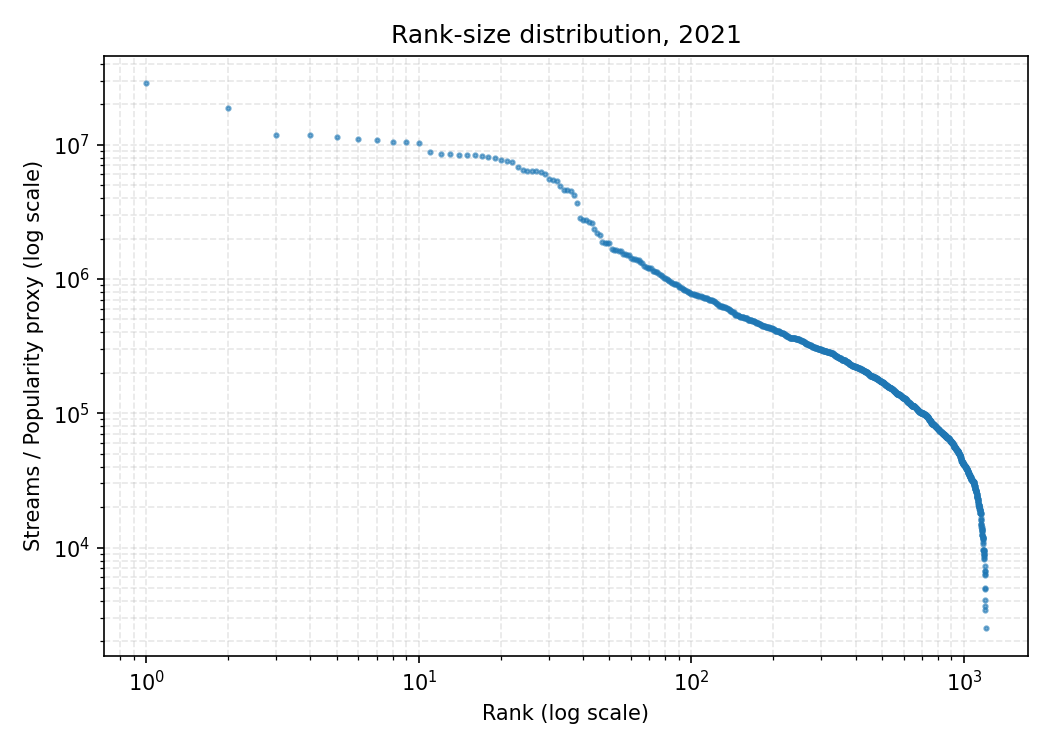

outputs/rank_size_2022.png


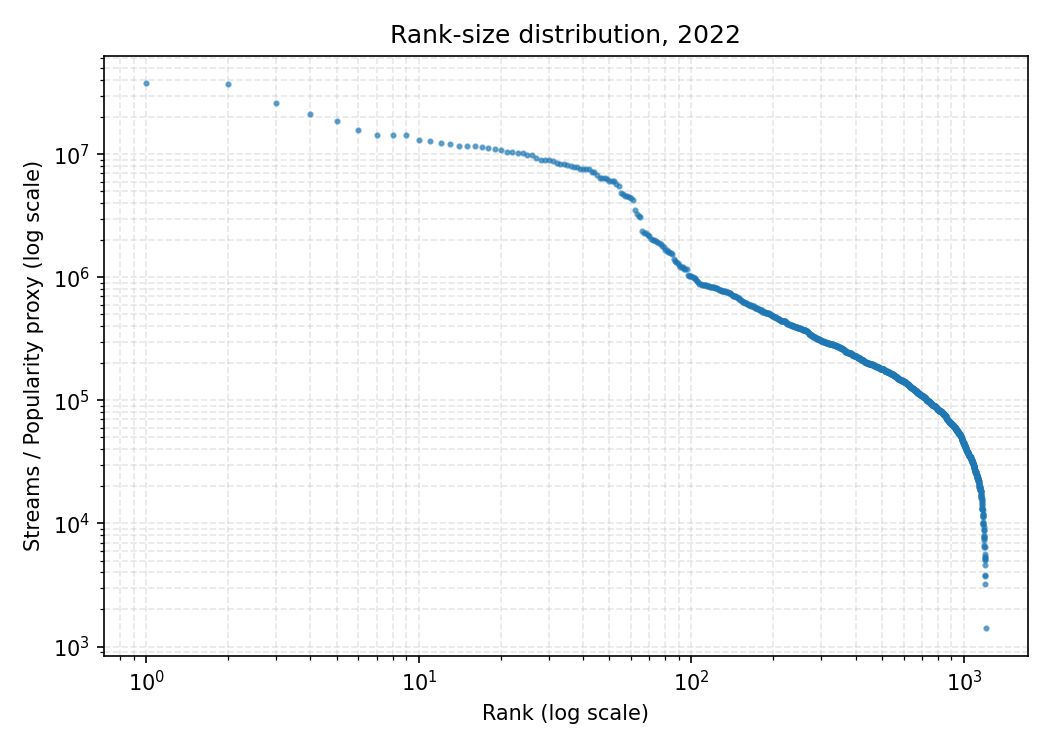

outputs/rank_size_2023.png


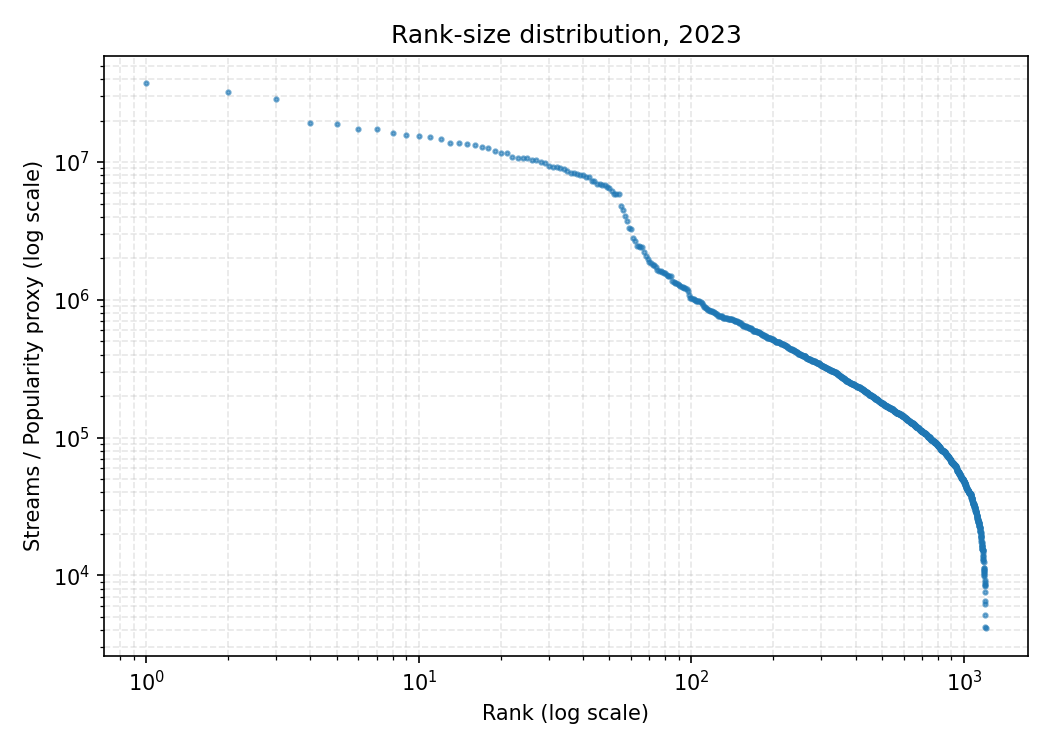

outputs/rank_size_2024.png


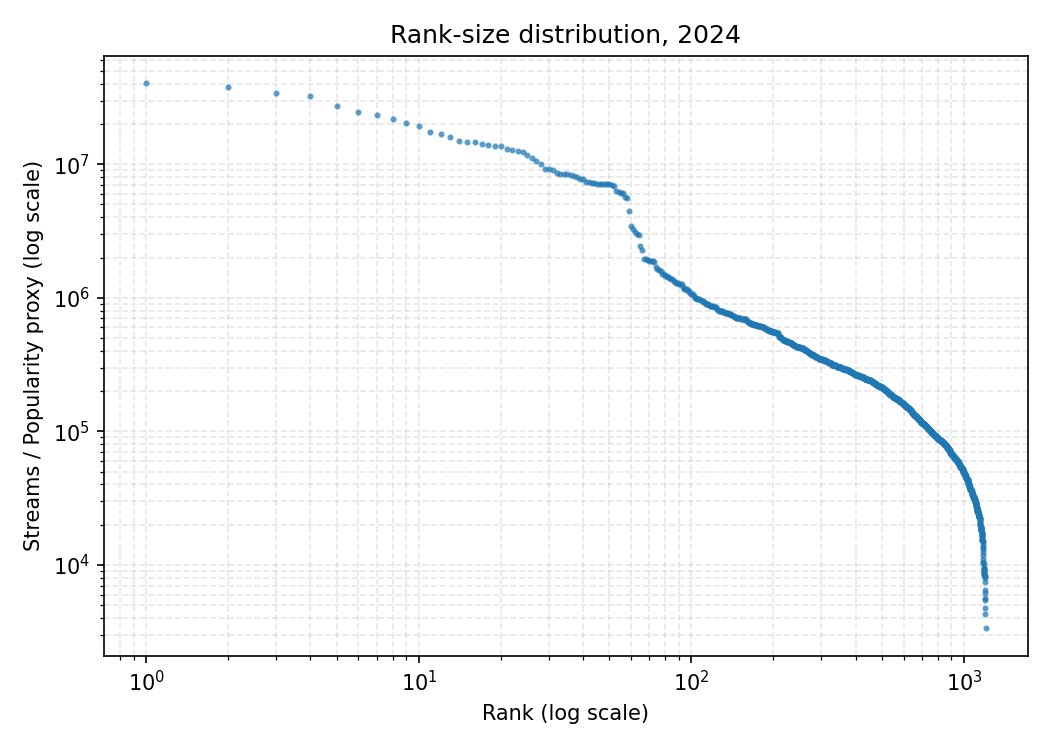

In [33]:
from IPython.display import Image, display
import glob

for path in sorted(glob.glob("outputs/*.png")):
    print(path)
    display(Image(filename=path))


## 6. View the result tables

In [34]:
import pandas as pd

print("Power-law fits by year:")
display(pd.read_csv("outputs/power_law_fits_by_year.csv"))

print("\nInequality metrics by year:")
display(pd.read_csv("outputs/inequality_by_year.csv"))


Power-law fits by year:


,label,alpha,xmin,ks_distance,n_obs_above_xmin,n_obs_total,power_law_vs_lognormal,power_law_vs_exponential,power_law_vs_truncated_power_law,power_law_vs_stretched_exponential,year
0,2014,1.964741,104252.0,0.037505,598,598,{'loglikelihood_ratio_R': np.float64(-0.007157...,{'loglikelihood_ratio_R': np.float64(483.22800...,{'loglikelihood_ratio_R': np.float64(-0.558280...,{'loglikelihood_ratio_R': np.float64(2.9556284...,2014
1,2015,1.910604,147496.0,0.037401,452,452,{'loglikelihood_ratio_R': np.float64(-0.015894...,{'loglikelihood_ratio_R': np.float64(358.29840...,{'loglikelihood_ratio_R': np.float64(-0.870230...,{'loglikelihood_ratio_R': np.float64(2.5222815...,2015
2,2016,2.030645,162552.0,0.053508,435,435,{'loglikelihood_ratio_R': np.float64(-0.123498...,{'loglikelihood_ratio_R': np.float64(275.29090...,{'loglikelihood_ratio_R': np.float64(-0.559768...,{'loglikelihood_ratio_R': np.float64(1.3696653...,2016
3,2017,2.018240,127744.0,0.031947,575,575,{'loglikelihood_ratio_R': np.float64(0.0072252...,{'loglikelihood_ratio_R': np.float64(424.03607...,{'loglikelihood_ratio_R': np.float64(-0.414481...,{'loglikelihood_ratio_R': np.float64(3.8231041...,2017
4,2018,1.964240,222721.0,0.039460,373,373,{'loglikelihood_ratio_R': np.float64(0.0088790...,{'loglikelihood_ratio_R': np.float64(262.94201...,{'loglikelihood_ratio_R': np.float64(-0.634109...,{'loglikelihood_ratio_R': np.float64(2.5995437...,2018
5,2019,1.952927,165081.0,0.041810,480,480,{'loglikelihood_ratio_R': np.float64(0.0046611...,{'loglikelihood_ratio_R': np.float64(348.26086...,{'loglikelihood_ratio_R': np.float64(-0.822649...,{'loglikelihood_ratio_R': np.float64(3.0143583...,2019
6,2020,1.897953,129389.0,0.036479,588,588,{'loglikelihood_ratio_R': np.float64(0.0040986...,{'loglikelihood_ratio_R': np.float64(483.63369...,{'loglikelihood_ratio_R': np.float64(-1.129585...,{'loglikelihood_ratio_R': np.float64(4.2060787...,2020
7,2021,1.995703,180821.0,0.035317,482,482,{'loglikelihood_ratio_R': np.float64(0.0008485...,{'loglikelihood_ratio_R': np.float64(306.91186...,{'loglikelihood_ratio_R': np.float64(-0.878805...,{'loglikelihood_ratio_R': np.float64(2.4597279...,2021
8,2022,1.818858,123068.0,0.038324,657,657,{'loglikelihood_ratio_R': np.float64(-0.104341...,{'loglikelihood_ratio_R': np.float64(569.42580...,{'loglikelihood_ratio_R': np.float64(-2.375164...,{'loglikelihood_ratio_R': np.float64(4.0176119...,2022
9,2023,1.791165,107661.0,0.037505,720,720,{'loglikelihood_ratio_R': np.float64(-0.829995...,{'loglikelihood_ratio_R': np.float64(636.83904...,{'loglikelihood_ratio_R': np.float64(-3.183831...,{'loglikelihood_ratio_R': np.float64(0.6293328...,2023



Inequality metrics by year:


,year,gini,theil,top_1pct_share,top_5pct_share,top_10pct_share,theil_within_genre,theil_between_genre
0,2014,0.789548,1.778497,0.337965,0.656372,0.735803,1.721560,0.056938
1,2015,0.816999,1.928783,0.337137,0.688474,0.769053,1.798929,0.129853
2,2016,0.761541,1.574929,0.308124,0.607182,0.690710,1.472430,0.102499
3,2017,0.770179,1.601447,0.290470,0.626833,0.711715,1.561220,0.040227
4,2018,0.798562,1.751058,0.331220,0.661693,0.744660,1.679230,0.071828
5,2019,0.789338,1.662794,0.283463,0.655992,0.737210,1.575376,0.087418
6,2020,0.806445,1.728386,0.276628,0.680525,0.763669,1.658349,0.070037
7,2021,0.767808,1.525358,0.256398,0.612557,0.707193,1.471900,0.053458
8,2022,0.820573,1.760298,0.261196,0.688899,0.789237,1.708003,0.052295
9,2023,0.821717,1.776764,0.263507,0.700328,0.789396,1.716250,0.060514
